In [ ]:
#加载模型和数据集

import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"

from transformers import AutoProcessor,AutoModelForImageTextToText,BitsAndBytesConfig
import torch


model_name = "SmolVLM2-2.2B-Instruct"
model = AutoModelForImageTextToText.from_pretrained(
    model_name,
    dtype=torch.bfloat16,
)
processor = AutoProcessor.from_pretrained(model_name,cache_dir=model_name)


/home/ai/anaconda3/envs/llama_factory/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version 2.10.0+cu128 for torchao version 0.15.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.95s/it]


In [2]:
# 加载数据集
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

from datasets import Dataset

# 从本地 csv 加载（1000 条 ChartQA 样本）
ds = Dataset.from_csv("chartqa.csv")

# 必须接住返回值，否则 ds 仍是整表，不会分出 train/test
ds = ds.train_test_split(test_size=0.1, seed=42)
ds



DatasetDict({
    train: Dataset({
        features: ['image', 'query', 'label', 'human_or_machine'],
        num_rows: 900
    })
    test: Dataset({
        features: ['image', 'query', 'label', 'human_or_machine'],
        num_rows: 100
    })
})

In [3]:
from transformers.image_utils import load_image

example = ds["train"][0]
image_url = example["image"]
image = load_image(image_url)

print(example['query'])
print(eval(example['label'])[0])


Is the difference between largest and smallest segment greater than median?
Yes


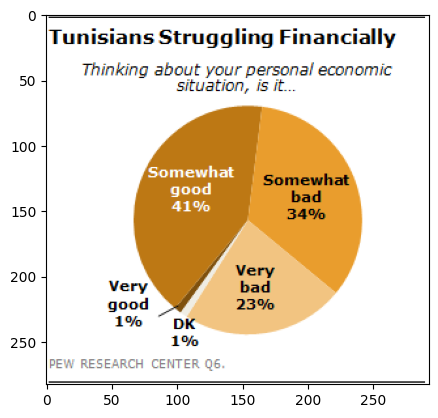

In [4]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.show()


In [5]:
# define a chat-style prompt
print(image)

messages = [
    {"role": "user", "content":[
        {"type": "image", "image": image},
         {"type": "text", "text": example['query']},
    ]
    }
]

#apply_chat_template
prompt = processor.apply_chat_template(messages,tokenize=False,add_generation_prompt=True)
print("input_prompt: ",prompt)

#推理

inputs = processor(images=[image],text=prompt, return_tensors="pt").to(model.device)
with torch.no_grad():
    outputs = model.generate(**inputs,max_new_tokens=20)

trimmed_generated_ids = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, outputs)]

out_text = processor.batch_decode(trimmed_generated_ids,skip_special_tokens=True,clean_up_tokenization_spaces=False)

print("output: ",out_text[0])




<PIL.Image.Image image mode=RGB size=293x283 at 0x70FA647F55D0>
input_prompt:  <|im_start|>User:<image>Is the difference between largest and smallest segment greater than median?<end_of_utterance>
Assistant:
output:   Yes.


In [6]:
system_message = """You are a Vision Language Model specialized in interpreting visual data from chart images.
Your task is to analyze the provided chart image and respond to queries with concise answers, usually a single word, number, or short phrase.
The charts include a variety of types (e.g., line charts, bar charts) and contain colors, labels, and text.
Focus on delivering accurate, succinct answers based on the visual information. Avoid additional explanation unless absolutely necessary."""

In [7]:


def clean_label(x):
    # 1. 全部转成字符串
    s = str(x)
    
    # 2. 去掉 [ ]
    s = s.replace("[", "").replace("]", "")
    
    # 3. 去掉所有引号 ' "
    s = s.replace("'", "").replace('"', "")
    
    # 4. 去掉多余空格（可选但推荐）
    s = s.strip()
    
    return s

In [20]:
#数据 formpt  trl 要求多模态数据集每个元素包含 images和messages
from PIL import Image

def format_data(example):
    try:
        image = load_image(example["image"])
        # print(image)
    except Exception as e:
        print(e)
        # 🌟 核心改进：创建一张 224x224 的白色纯色图代替 None 兜底，绝不破坏数据结构
        image = Image.new("RGB", (224, 224), color="white")
        
    #解析label
    return {
        "images": [image],
        "messages": [
            {"role": "system", "content":[{"type": "text", "text": system_message}]},
            {"role": "user", "content": [
                {"type": "text", "text": example["query"]},
                {"type": "image", "image": image},
            ]},
            {"role": "assistant", "content": [
                {"type": "text", "text": clean_label(example["label"])}
            ]}
        ]
    }

train_sub_dataset = ds["train"].select(range(200))

train_dataset = train_sub_dataset.map(
    format_data, 
    remove_columns=train_sub_dataset.column_names
)

eval_dataset = ds["test"].map(
    format_data, 
    remove_columns=ds["test"].column_names
)


Map:  80%|████████  | 161/200 [00:38<00:07,  5.00 examples/s]

cannot identify image file <_io.BytesIO object at 0x70f6d54b6570>


Map: 100%|██████████| 100/100 [00:25<00:00,  3.97 examples/s]


In [13]:
train_dataset[0]

{'images': [<PIL.Image.Image image mode=RGB size=293x283>],
 'messages': [{'role': 'system',
   'content': [{'type': 'text',
     'text': 'You are a Vision Language Model specialized in interpreting visual data from chart images.\nYour task is to analyze the provided chart image and respond to queries with concise answers, usually a single word, number, or short phrase.\nThe charts include a variety of types (e.g., line charts, bar charts) and contain colors, labels, and text.\nFocus on delivering accurate, succinct answers based on the visual information. Avoid additional explanation unless absolutely necessary.'}]},
  {'role': 'user',
   'content': [{'type': 'text',
     'text': 'Is the difference between largest and smallest segment greater than median?'},
    {'type': 'image',
     'image': <PIL.Image.Image image mode=RGB size=293x283>}]},
  {'role': 'assistant', 'content': [{'type': 'text', 'text': 'Yes'}]}]}

In [14]:
from peft import LoraConfig,get_peft_model,TaskType

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_proj","v_proj"],
    task_type="CAUSAL_LM",
)

model = get_peft_model(model,lora_config)

model.print_trainable_parameters()


trainable params: 2,568,192 || all params: 2,249,353,072 || trainable%: 0.1142


/home/ai/anaconda3/envs/llama_factory/lib/python3.11/site-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(


In [ ]:
from trl import SFTConfig, SFTTrainer

# Configure training arguments using SFTConfig
training_args = SFTConfig(
    output_dir="smolvlm2-2.2b-instruct-trl-sft-ChartQA",
    num_train_epochs=1,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=8,
    learning_rate=1e-4,
    logging_steps=25,
    save_strategy="steps",
    save_steps=25,
    optim="adamw_torch_fused",
    bf16=True,
    # report_to="trackio",
    max_length=None,
)

# Initialize the Trainer
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    peft_config=lora_config,
)

# Align the SFTTrainer params with your chosen dataset.

/home/ai/anaconda3/envs/llama_factory/lib/python3.11/site-packages/peft/tuners/lora/bnb.py:397: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(
/home/ai/anaconda3/envs/llama_factory/lib/python3.11/site-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [22]:
trainer.train()

RuntimeError: Index put requires the source and destination dtypes match, got BFloat16 for the destination and Float for the source.